<a href="https://colab.research.google.com/github/LuanLindolfo/Mineracao_de_Dados/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/mineração de dados aula/student_dataset_10000_rows.csv')
display(df)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
...,...,...,...,...,...,...,...,...
9995,2,58,9,7,8,88,69.31,Not Placed
9996,7,98,6,9,4,87,100.00,Placed
9997,10,44,8,5,10,37,95.94,Placed
9998,10,75,7,5,8,52,88.61,Placed


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#verifica se há dados faltantes
nulos_por_coluna = df.isnull().sum()
print(nulos_por_coluna) # Mostra apenas as colunas que têm dados faltando


study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64


In [ ]:
# definindo os limites de corte das notas.
# 0 a 70 (baixo), 70 a 90 (Mmdio), 90 a 100 (alto)
limites = [0, 70, 90, 100.1]
rotulos = ['Baixo', 'Médio', 'Alto']

df['faixa_rendimento'] = pd.cut(df['exam_score'], bins=limites, labels=rotulos)

In [ ]:
print("Distribuição das Faixas de Rendimento:")
print(df['faixa_rendimento'].value_counts())

Distribuição das Faixas de Rendimento:
faixa_rendimento
Alto     5381
Médio    2975
Baixo    1644
Name: count, dtype: int64


In [ ]:
#definindo X e Y
X = df.drop(columns=['exam_score', 'faixa_rendimento', 'placement_status'])
Y = df['faixa_rendimento']


In [ ]:
#codificando as variáveis categóricas em X
labelencoder_X = LabelEncoder()
for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = labelencoder_X.fit_transform(X[col].astype(str))

In [ ]:
#codificando Y para números
labelencoder_Y = LabelEncoder()
Y_encoded = labelencoder_Y.fit_transform(Y)

KNN com K-Fold

In [ ]:

print("\n" + "="*60)
print("INICIANDO MODELO 1: KNN COM K-FOLD")
print("="*60)

# Padronização
sc_knn = StandardScaler()
X_knn = sc_knn.fit_transform(X)

# Definindo modelo KNN
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')

#
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

cvscores = []

for fold, (train_index, test_index) in enumerate(kf.split(X_knn), 1):
    print(f'\n*------------------- FOLD {fold} -------------------*')
    X_train_k, X_test_k = X_knn[train_index], X_knn[test_index]
    Y_train_k, Y_test_k = Y_encoded[train_index], Y_encoded[test_index]

    # Treinamento e Predição
    knn.fit(X_train_k, Y_train_k)
    y_pred_k = knn.predict(X_test_k)

    # Avaliação
    score = knn.score(X_test_k, Y_test_k)
    cvscores.append(score)
    print(classification_report(Y_test_k, y_pred_k, target_names=labelencoder_Y.classes_))

print(f"\n=> Acurácia em cada fold: {[round(s, 4) for s in cvscores]}")
print(f"=> Acurácia média do KNN: {np.mean(cvscores):.4f}")


INICIANDO MODELO 1: KNN COM K-FOLD

*------------------- FOLD 1 -------------------*
              precision    recall  f1-score   support

        Alto       0.77      0.86      0.81      1069
       Baixo       0.65      0.54      0.59       345
       Médio       0.50      0.45      0.48       586

    accuracy                           0.69      2000
   macro avg       0.64      0.62      0.63      2000
weighted avg       0.67      0.69      0.68      2000


*------------------- FOLD 2 -------------------*
              precision    recall  f1-score   support

        Alto       0.75      0.85      0.80      1043
       Baixo       0.60      0.56      0.58       306
       Médio       0.54      0.44      0.49       651

    accuracy                           0.68      2000
   macro avg       0.63      0.62      0.62      2000
weighted avg       0.66      0.68      0.66      2000


*------------------- FOLD 3 -------------------*
              precision    recall  f1-score   suppor

SVM COM TRAIN/TEST SPLIT

In [ ]:
#Divisão dos dados: 80% treino, 20% teste
X_train_svm, X_test_svm, Y_train_svm, Y_test_svm = train_test_split(X, Y_encoded, shuffle=True, test_size=0.2, random_state=42)

In [ ]:
# Padronização
scaler_svm = StandardScaler()
X_train_svm = scaler_svm.fit_transform(X_train_svm)
X_test_svm = scaler_svm.transform(X_test_svm)

In [ ]:
# Treinamento
clf = SVC(kernel='poly', gamma=0.5, C=100)
clf.fit(X_train_svm, Y_train_svm)

SVC(C=100, gamma=0.5, kernel='poly')

In [ ]:
#Predição
y_pred_svm = clf.predict(X_test_svm)

In [ ]:
print("\nRelatório de Classificação do SVM:")
print(classification_report(Y_test_svm, y_pred_svm, target_names=labelencoder_Y.classes_))


Relatório de Classificação do SVM:
              precision    recall  f1-score   support

        Alto       0.84      0.91      0.88      1069
       Baixo       0.81      0.53      0.64       345
       Médio       0.60      0.64      0.62       586

    accuracy                           0.76      2000
   macro avg       0.75      0.69      0.71      2000
weighted avg       0.77      0.76      0.76      2000



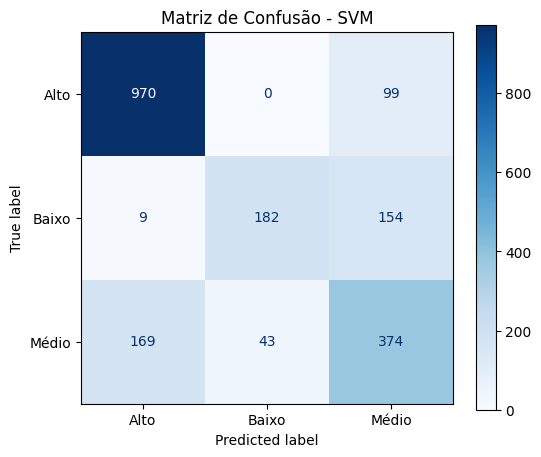

In [ ]:
#matriz de confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    Y_test_svm,
    y_pred_svm,
    display_labels=labelencoder_Y.classes_,
    cmap='Blues',
    ax=ax
)
plt.title('Matriz de Confusão - SVM')
plt.grid(False)
plt.show()

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#Definindo o modelo com 100 arvores de decisão
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

In [ ]:
# Treinamento do modelo
rf.fit(X_train_svm, Y_train_svm)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
# Predição
y_pred_rf = rf.predict(X_test_svm)

In [ ]:
# Relatório de Avaliação do Random Forest
print("\nRelatório de Classificação do Random Forest:")
print(classification_report(Y_test_svm, y_pred_rf, target_names=labelencoder_Y.classes_))


Relatório de Classificação do Random Forest:
              precision    recall  f1-score   support

        Alto       0.83      0.89      0.86      1069
       Baixo       0.73      0.56      0.63       345
       Médio       0.56      0.56      0.56       586

    accuracy                           0.74      2000
   macro avg       0.71      0.67      0.68      2000
weighted avg       0.73      0.74      0.73      2000



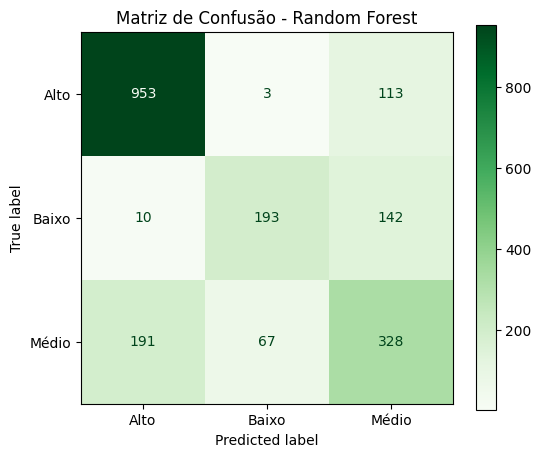

In [ ]:
# Gerando a Matriz de Confusão do Random Forest
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    Y_test_svm,
    y_pred_rf,
    display_labels=labelencoder_Y.classes_,
    cmap='Greens',
    ax=ax
)
plt.title('Matriz de Confusão - Random Forest')
plt.grid(False)
plt.show()

In [ ]:
import pickle

dados_modelo = {
    'model': clf,              # modelo SVM treinado
    'scaler': scaler_svm,      # scaler usado no treino
    'label_encoder': labelencoder_Y,
    'colunas': list(X.columns)
}

# Salva na raiz do Drive (ajuste o caminho se quiser outra pasta)
with open('/content/drive/MyDrive/modelo_svm_alunos.pkl', 'wb') as f:
    pickle.dump(dados_modelo, f)

print("✅ Modelo SVM salvo no Drive!")
print("Colunas:", list(X.columns))
print("Classes:", list(labelencoder_Y.classes_))



✅ Modelo SVM salvo no Drive!
Colunas: ['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score']
Classes: ['Alto', 'Baixo', 'Médio']
